In [ ]:
# CELL: Fix corrupted package metadata + re-pin (REPLACES the previous re-pin line)

# 1. Find and remove any mangled dist-info left over from the interrupted upgrade
!find /usr/local/lib/python3.12/dist-packages -maxdepth 1 -name "~*" -exec rm -rf {} \;

# 2. Force-reinstall the three packages (--force-reinstall bypasses pip trying to
#    diff against the broken metadata; --no-deps avoids pulling unrelated dependency
#    changes that could re-trigger the same conflict)
!pip install --force-reinstall --no-deps -q \
    nvidia-cudnn-cu12==9.19.0.56 \
    nvidia-cusparselt-cu12==0.7.1 \
    nvidia-nccl-cu12==2.28.9

# 3. Confirm the fix actually took
!pip show nvidia-cudnn-cu12 | grep -i version
!pip show nvidia-cusparselt-cu12 | grep -i version
!pip show nvidia-nccl-cu12 | grep -i version

Version: 9.19.0.56
Version: 0.7.1
Version: 2.28.9


In [ ]:
# ============================================================
# CELL: Sanity check install (UPDATED)
# Changed: removed `import paddle` immediately followed by paddleocr use in
# the same flow — now checks torch AND paddle, and deliberately does NOT
# import paddleocr here. Importing paddleocr initializes PaddleX's global
# registry; doing that in a "just checking" cell risks a partial failure
# that then blocks the real import later with a RuntimeError.
# ============================================================
import torch
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

import paddle
print("paddle:", paddle.__version__, "| CUDA:", paddle.device.is_compiled_with_cuda())

torch: 2.11.0+cu128 | CUDA: True


/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


paddle: 3.3.1 | CUDA: True


In [ ]:
# ============================================================
# CELL: Git-lfs pull sample data — UNCHANGED from original notebook
# ============================================================
!apt-get -qq install git-lfs
!git lfs install

!git clone --depth 1 https://github.com/bankh/CatalogBank.git /content/CatalogBank
%cd /content/CatalogBank
!git lfs pull -I "Catalogs/Sample/Thorlabs/OptoMechanics_v21/_pdfs/*,Catalogs/Sample/Thorlabs/OptoMechanics_v21/_images/*,Catalogs/Sample/McMasterCarr/_pdfs/*,Catalogs/Sample/McMasterCarr/_images/*"
%cd /content

Git LFS initialized.
fatal: destination path '/content/CatalogBank' already exists and is not an empty directory.
/content/CatalogBank
/content


In [ ]:
# ============================================================
# CELL: Pick sample pages — UNCHANGED
# ============================================================
import glob, random, os

thorlabs_pdfs = sorted(glob.glob("/content/CatalogBank/Catalogs/Sample/Thorlabs/OptoMechanics_v21/_pdfs/*.pdf"))
mcmaster_pdfs = sorted(glob.glob("/content/CatalogBank/Catalogs/Sample/McMasterCarr/_pdfs/*.pdf"))

random.seed(42)
sample_pdfs = random.sample(thorlabs_pdfs, min(3, len(thorlabs_pdfs))) + \
              random.sample(mcmaster_pdfs, min(3, len(mcmaster_pdfs)))
print(f"{len(sample_pdfs)} sample pages selected")

6 sample pages selected


In [ ]:
# ============================================================
# CELL: Rasterize PDFs to images — UNCHANGED
# ============================================================
import fitz  # pymupdf

os.makedirs("/content/page_images", exist_ok=True)

def pdf_to_image(pdf_path, out_dir="/content/page_images", dpi=200):
    doc = fitz.open(pdf_path)
    page = doc[0]
    mat = fitz.Matrix(dpi / 72, dpi / 72)
    pix = page.get_pixmap(matrix=mat)
    out_path = os.path.join(out_dir, os.path.splitext(os.path.basename(pdf_path))[0] + ".png")
    pix.save(out_path)
    doc.close()
    return out_path

image_paths = [pdf_to_image(p) for p in sample_pdfs]
image_paths

['/content/page_images/V21_1_Optomechanics_45.png',
 '/content/page_images/V21_1_Optomechanics_15.png',
 '/content/page_images/V21_1_Optomechanics_1.png',
 '/content/page_images/mcmaster-125_3378_7.png',
 '/content/page_images/mcmaster-125_3378_24.png',
 '/content/page_images/mcmaster-125_3378_22.png']

In [ ]:
# ============================================================
# CELL: Run structure extraction (REPLACED)
# The old cell used `from paddleocr import PPStructure` and called it as
# `structure_engine(img_path)`, returning a list of dicts with `type`,
# `bbox`, `res`. That class is 2.x-era API and no longer matches what
# paddleocr 3.7.0 installs. Replaced with PPStructureV3, using its
# `.predict()` + `.save_to_json()` / `.save_to_markdown()` interface.
# This must be the FIRST paddleocr import this session — run it once.
# ============================================================
from paddleocr import PPStructureV3

os.makedirs("/content/output/ppstructurev3", exist_ok=True)

pp_structure = PPStructureV3()

pp_structure_results = {}
for img_path in image_paths:
    stem = os.path.splitext(os.path.basename(img_path))[0]
    out_dir = f"/content/output/ppstructurev3/{stem}"
    os.makedirs(out_dir, exist_ok=True)

    for res in pp_structure.predict(img_path):
        res.save_to_json(save_path=out_dir)
        res.save_to_markdown(save_path=out_dir)
        res.save_to_img(save_path=out_dir)   # built-in visualization, replaces the old cv2 draw_regions() cell
        pp_structure_results[img_path] = res
    print(f"{stem}: done -> {out_dir}")

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('UVDoc', None, None)
Using official model (UVDoc), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/UVDoc`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

Creating model: ('PP-FormulaNet_plus-L', None, None)
Using official model (PP-FormulaNet_plus-L), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-FormulaNet_plus-L`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_rec`.
Connecting to https://paddle-model-ecology.bj.bcebos.com/paddlex/PaddleX3.0/fonts/PingFang-SC-Regular.ttf ...
[===============================================

V21_1_Optomechanics_45: done -> /content/output/ppstructurev3/V21_1_Optomechanics_45
V21_1_Optomechanics_15: done -> /content/output/ppstructurev3/V21_1_Optomechanics_15
V21_1_Optomechanics_1: done -> /content/output/ppstructurev3/V21_1_Optomechanics_1
mcmaster-125_3378_7: done -> /content/output/ppstructurev3/mcmaster-125_3378_7
mcmaster-125_3378_24: done -> /content/output/ppstructurev3/mcmaster-125_3378_24
mcmaster-125_3378_22: done -> /content/output/ppstructurev3/mcmaster-125_3378_22


In [ ]:
# ============================================================
# CELL: Inspect actual output schema before normalizing (NEW)
# I don't want to hand you a normalize_page() function that guesses at
# JSON key names for the 3.x output — the schema differs from the old
# `type`/`bbox`/`res` dict shape. Run this first and look at the printed
# keys/structure, then we write the real normalizer against what's
# actually there.
# ============================================================
import json

sample_stem = os.path.splitext(os.path.basename(image_paths[0]))[0]
json_path = glob.glob(f"/content/output/ppstructurev3/{sample_stem}/*.json")[0]

with open(json_path) as f:
    data = json.load(f)

print("Top-level keys:", list(data.keys()))
print(json.dumps(data, indent=2)[:2000])

Top-level keys: ['input_path', 'page_index', 'page_count', 'width', 'height', 'model_settings', 'parsing_res_list', 'doc_preprocessor_res', 'layout_det_res', 'overall_ocr_res', 'table_res_list']
{
  "input_path": "/content/page_images/V21_1_Optomechanics_45.png",
  "page_index": null,
  "page_count": null,
  "width": 1700,
  "height": 2150,
  "model_settings": {
    "use_doc_preprocessor": true,
    "use_seal_recognition": false,
    "use_table_recognition": true,
    "use_formula_recognition": true,
    "use_chart_recognition": false,
    "use_region_detection": true,
    "format_block_content": false,
    "markdown_ignore_labels": [
      "number",
      "footnote",
      "header",
      "header_image",
      "footer",
      "footer_image",
      "aside_text"
    ]
  },
  "parsing_res_list": [
    {
      "block_label": "paragraph_title",
      "block_content": "Faraday Enclosure External Post Adapter ",
      "block_bbox": [
        0,
        42,
        1070,
        82
      ],
 

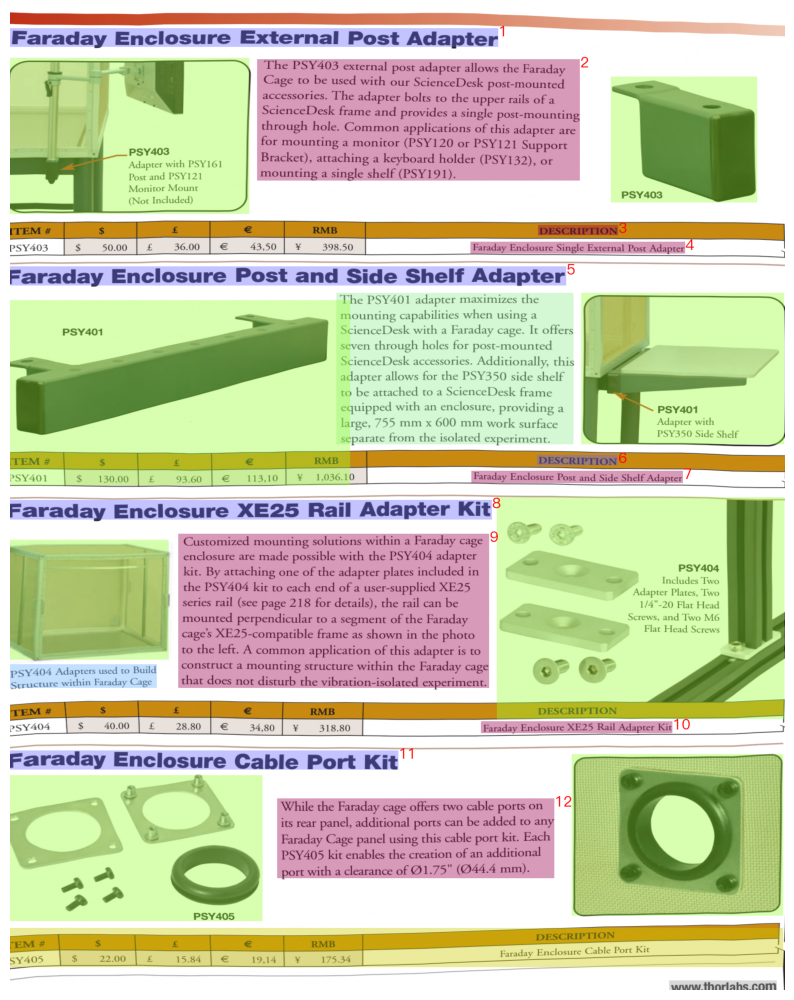

In [ ]:
# ============================================================
# CELL: Visualize — REPLACED
# The old cell manually drew bboxes with cv2 based on region['bbox']/['type'].
# That schema doesn't apply anymore. res.save_to_img() above already wrote
# an annotated visualization to disk — just display it.
# ============================================================
from PIL import Image
import matplotlib.pyplot as plt

vis_path = glob.glob(f"/content/output/ppstructurev3/{sample_stem}/*.png")[0]
img = Image.open(vis_path)
plt.figure(figsize=(10,14))
plt.imshow(img)
plt.axis("off")
plt.show()